# Extraction of logarithms of Mel-scale Filterbank energies

In [ ]:
from google.colab import files
files.upload()

In [2]:
from typing import Optional
import torch
from torch import nn
from torchaudio import functional as F
import torchaudio
import matplotlib.pyplot as plt

In [3]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()

        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        window = torch.hann_window(self.window_length)
        self.register_buffer("window", window)
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power
        self.f_min_hz = f_min_hz
        self.f_max_hz = samplerate / 2 if f_max_hz is None else f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale
        mel_fbanks = self._init_melscale_fbanks()
        self.register_buffer("mel_fbanks", mel_fbanks)

    def _init_melscale_fbanks(self):
        if self.onesided:
            n_freqs = self.n_fft // 2 + 1
        else:
            n_freqs = self.n_fft

        return F.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale
        )

    def spectrogram(self, x):
        window = self.window.to(device=x.device, dtype=x.dtype)
        stft = torch.stft(
            input=x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )
        if self.return_complex:
            spec = torch.abs(stft) ** self.power
        else:
            spec = torch.abs(torch.view_as_complex(stft)) ** self.power
        return spec

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)

        spec = self.spectrogram(x)
        mel_fbanks = self.mel_fbanks.to(device=spec.device, dtype=spec.dtype)
        spec = spec.transpose(-2, -1)
        mel_spec = spec @ mel_fbanks
        mel_spec = mel_spec.transpose(-2, -1)
        log_mel_spec = torch.log(mel_spec + 1e-6)
        return log_mel_spec

In [4]:
wav_path = "/content/example_16k.wav"
signal, sr = torchaudio.load(wav_path)

In [5]:
melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)

logmel_layer = LogMelFilterBanks()
logmelbanks = logmel_layer(signal)

assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks)
print("True")

True


In [6]:
ref_logmel = torch.log(melspec + 1e-6)
our_logmel = logmelbanks
diff = torch.abs(ref_logmel - our_logmel)

In [7]:
print("max abs diff  =", diff.max().item())
print("mean abs diff =", diff.mean().item())

max abs diff  = 0.0
mean abs diff = 0.0


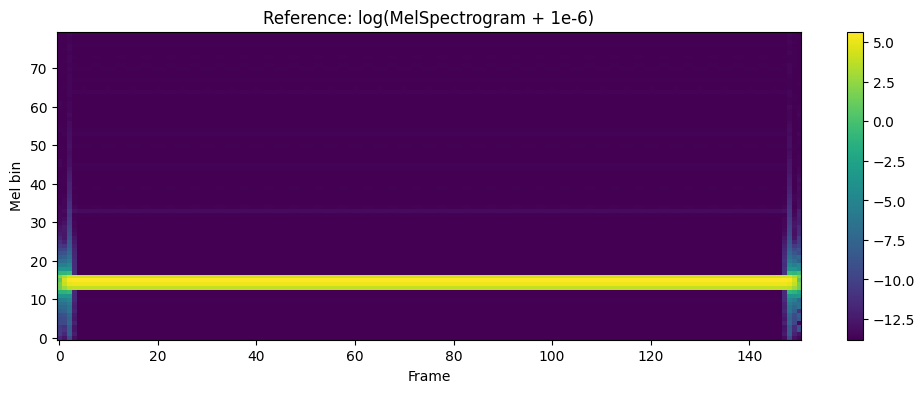

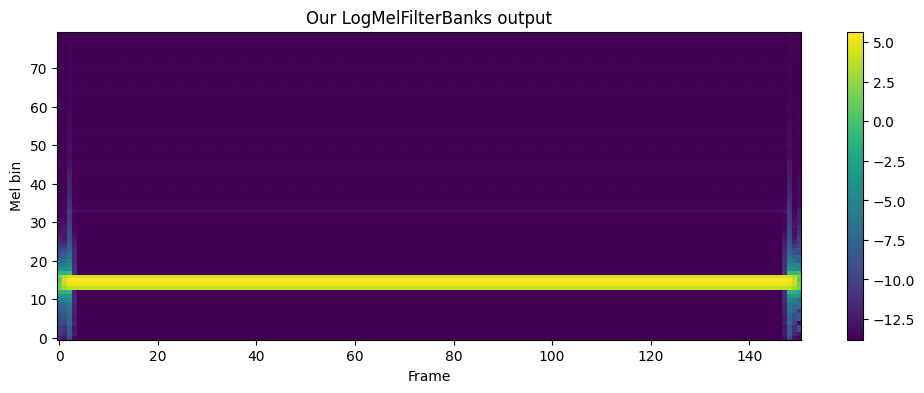

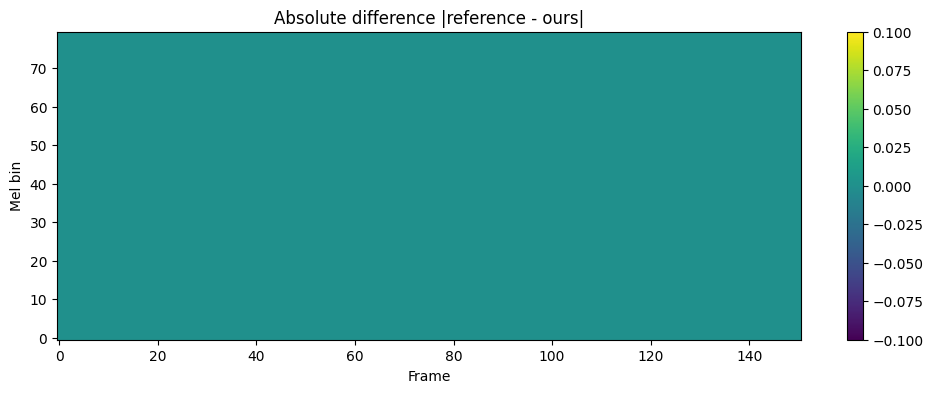

In [8]:
plt.figure(figsize=(12, 4))
plt.imshow(ref_logmel.squeeze(0).cpu().numpy(), aspect='auto', origin='lower')
plt.title("Reference: log(MelSpectrogram + 1e-6)")
plt.xlabel("Frame")
plt.ylabel("Mel bin")
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(our_logmel.squeeze(0).detach().cpu().numpy(), aspect='auto', origin='lower')
plt.title("Our LogMelFilterBanks output")
plt.xlabel("Frame")
plt.ylabel("Mel bin")
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(diff.squeeze(0).detach().cpu().numpy(), aspect='auto', origin='lower')
plt.title("Absolute difference |reference - ours|")
plt.xlabel("Frame")
plt.ylabel("Mel bin")
plt.colorbar()
plt.show()

# CNN model

In [10]:
!pip -q install thop pandas

In [11]:
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F_nn
from torch.utils.data import Dataset, DataLoader

import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS

from thop import profile

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [18]:
ROOT = "/content/speechcommands_data"
Path(ROOT).mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 128
NUM_WORKERS = 2
EPOCHS = 10
LEARNING_RATE = 1e-3
TARGET_SR = 16000
TARGET_NUM_SAMPLES = 16000

LABEL2ID = {"no": 0, "yes": 1}
ID2LABEL = {0: "no", 1: "yes"}

In [19]:
class YesNoSpeechCommands(Dataset):
    def __init__(self, root, subset=None, download=False):
        self.base = SPEECHCOMMANDS(root=root, subset=subset, download=download)
        self.indices = []

        for i in range(len(self.base)):
            _, _, label, _, _ = self.base.get_metadata(i)
            if label in LABEL2ID:
                self.indices.append(i)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        waveform, sample_rate, label, speaker_id, utterance_number = self.base[self.indices[idx]]
        return waveform, sample_rate, label

In [20]:
def pad_or_trim(waveform, num_samples=TARGET_NUM_SAMPLES):
    if waveform.size(1) > num_samples:
        waveform = waveform[:, :num_samples]
    elif waveform.size(1) < num_samples:
        pad_amount = num_samples - waveform.size(1)
        waveform = F_nn.pad(waveform, (0, pad_amount))
    return waveform


def collate_fn(batch):
    waveforms = []
    labels = []

    for waveform, sample_rate, label in batch:
        if waveform.size(0) > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != TARGET_SR:
            raise ValueError(f"Expected sample rate {TARGET_SR}, got {sample_rate}")

        waveform = pad_or_trim(waveform, TARGET_NUM_SAMPLES)
        waveforms.append(waveform.squeeze(0))
        labels.append(LABEL2ID[label])

    waveforms = torch.stack(waveforms, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return waveforms, labels

In [21]:
train_dataset = YesNoSpeechCommands(ROOT, subset="training", download=True)
val_dataset = YesNoSpeechCommands(ROOT, subset="validation", download=True)
test_dataset = YesNoSpeechCommands(ROOT, subset="testing", download=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 2.26G/2.26G [00:19<00:00, 122MB/s]


(6358, 803, 824)

In [22]:
class ConvKeywordClassifier(nn.Module):
    def __init__(self, n_mels=80, groups=1, num_classes=2, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_mels, 64, kernel_size=5, padding=2, groups=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 64, kernel_size=5, padding=2, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2, groups=groups),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [23]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_num_frames(n_mels):
    feature_extractor = LogMelFilterBanks(n_mels=n_mels)
    with torch.no_grad():
        dummy_waveform = torch.randn(1, TARGET_NUM_SAMPLES)
        dummy_features = feature_extractor(dummy_waveform)
    return dummy_features.shape[-1]


def compute_model_complexity(model, n_mels):
    num_frames = get_num_frames(n_mels)
    dummy_input = torch.randn(1, n_mels, num_frames)

    model_cpu = copy.deepcopy(model).cpu().eval()
    macs, params = profile(model_cpu, inputs=(dummy_input,), verbose=False)

    return {
        "params_trainable": count_trainable_parameters(model),
        "params_thop": int(params),
        "macs": float(macs),
        "flops": float(macs * 2),
        "num_frames": int(num_frames),
    }

In [24]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct, total


def extract_logmel_features(waveforms, feature_extractor, device):
    waveforms = waveforms.to(device, non_blocking=True)
    with torch.no_grad():
        features = feature_extractor(waveforms)
    return features


def run_one_epoch(model, feature_extractor, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for waveforms, labels in loader:
        labels = labels.to(device, non_blocking=True)
        features = extract_logmel_features(waveforms, feature_extractor, device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(features)
                loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        correct, total = accuracy_from_logits(logits, labels)
        total_correct += correct
        total_samples += total

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [25]:
def train_and_evaluate(
    n_mels=80,
    groups=1,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device,
):
    feature_extractor = LogMelFilterBanks(n_mels=n_mels).to(device)
    feature_extractor.eval()

    model = ConvKeywordClassifier(n_mels=n_mels, groups=groups).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time_sec": [],
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.perf_counter()

        train_loss, train_acc = run_one_epoch(
            model=model,
            feature_extractor=feature_extractor,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = run_one_epoch(
            model=model,
            feature_extractor=feature_extractor,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
        )

        epoch_time = time.perf_counter() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time_sec"].append(epoch_time)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"epoch={epoch + 1:02d} | "
            f"n_mels={n_mels} | groups={groups} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    model.load_state_dict(best_state)

    test_loss, test_acc = run_one_epoch(
        model=model,
        feature_extractor=feature_extractor,
        loader=test_loader,
        criterion=criterion,
        optimizer=None,
        device=device,
    )

    complexity = compute_model_complexity(model, n_mels=n_mels)

    result = {
        "n_mels": n_mels,
        "groups": groups,
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "mean_epoch_time_sec": float(np.mean(history["epoch_time_sec"])),
        "params_trainable": complexity["params_trainable"],
        "params_thop": complexity["params_thop"],
        "macs": complexity["macs"],
        "flops": complexity["flops"],
        "num_frames": complexity["num_frames"],
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict()),
    }

    print(
        f"FINAL | n_mels={n_mels} | groups={groups} | "
        f"best_val_acc={best_val_acc:.4f} | test_acc={test_acc:.4f} | "
        f"params={complexity['params_trainable']} | flops={complexity['flops']:.0f}"
    )

    return result

In [26]:
baseline_model = ConvKeywordClassifier(n_mels=80, groups=1)
print("Trainable parameters:", count_trainable_parameters(baseline_model))

Trainable parameters: 88066


In [27]:
n_mels_values = [20, 40, 80]

n_mels_results = []

for n_mels in n_mels_values:
    result = train_and_evaluate(
        n_mels=n_mels,
        groups=1,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device,
    )
    n_mels_results.append(result)

epoch=01 | n_mels=20 | groups=1 | train_loss=0.1987 | train_acc=0.9325 | val_loss=0.1005 | val_acc=0.9639 | time=26.13s
epoch=02 | n_mels=20 | groups=1 | train_loss=0.0854 | train_acc=0.9703 | val_loss=0.0733 | val_acc=0.9813 | time=19.70s
epoch=03 | n_mels=20 | groups=1 | train_loss=0.0586 | train_acc=0.9810 | val_loss=0.0610 | val_acc=0.9689 | time=22.57s
epoch=04 | n_mels=20 | groups=1 | train_loss=0.0434 | train_acc=0.9865 | val_loss=0.0397 | val_acc=0.9851 | time=21.51s
epoch=05 | n_mels=20 | groups=1 | train_loss=0.0391 | train_acc=0.9873 | val_loss=0.0379 | val_acc=0.9888 | time=21.84s
epoch=06 | n_mels=20 | groups=1 | train_loss=0.0300 | train_acc=0.9893 | val_loss=0.0261 | val_acc=0.9900 | time=22.02s
epoch=07 | n_mels=20 | groups=1 | train_loss=0.0287 | train_acc=0.9899 | val_loss=0.0307 | val_acc=0.9875 | time=22.44s
epoch=08 | n_mels=20 | groups=1 | train_loss=0.0223 | train_acc=0.9925 | val_loss=0.0262 | val_acc=0.9888 | time=19.46s
epoch=09 | n_mels=20 | groups=1 | train_

In [28]:
n_mels_table = pd.DataFrame([
    {
        "n_mels": r["n_mels"],
        "groups": r["groups"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "test_loss": r["test_loss"],
        "mean_epoch_time_sec": r["mean_epoch_time_sec"],
        "params_trainable": r["params_trainable"],
        "flops": r["flops"],
    }
    for r in n_mels_results
])

n_mels_table = n_mels_table.sort_values("n_mels").reset_index(drop=True)
n_mels_table

,n_mels,groups,best_val_acc,test_acc,test_loss,mean_epoch_time_sec,params_trainable,flops
0,20,1,0.990037,0.996359,0.013378,21.635016,68866,5498880.0
1,40,1,0.988792,0.990291,0.036777,20.522932,75266,6791680.0
2,80,1,0.986301,0.991505,0.023296,19.996228,88066,9377280.0


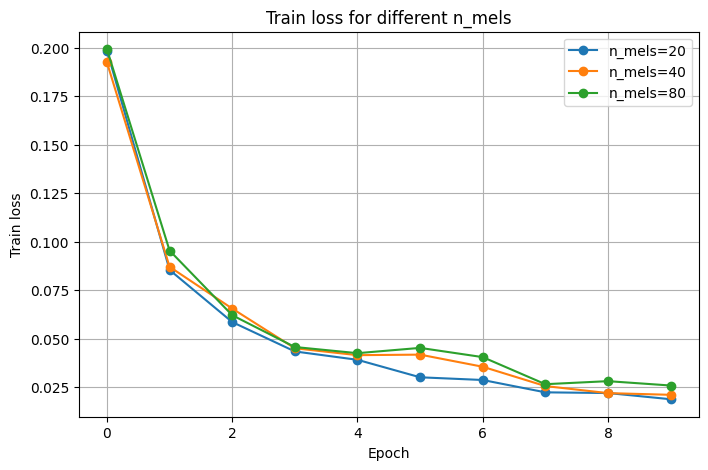

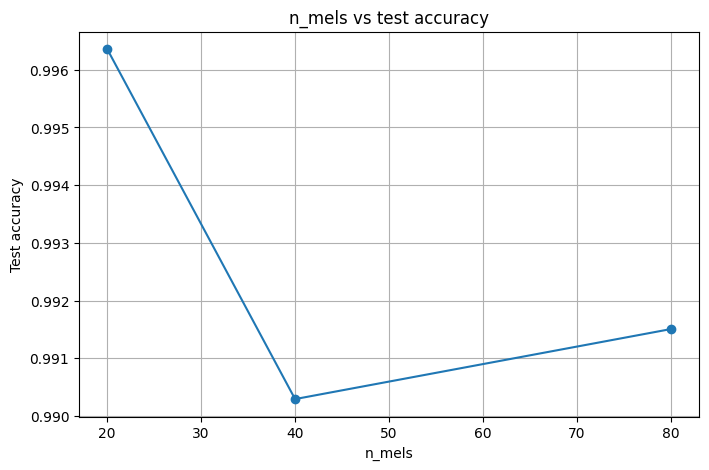

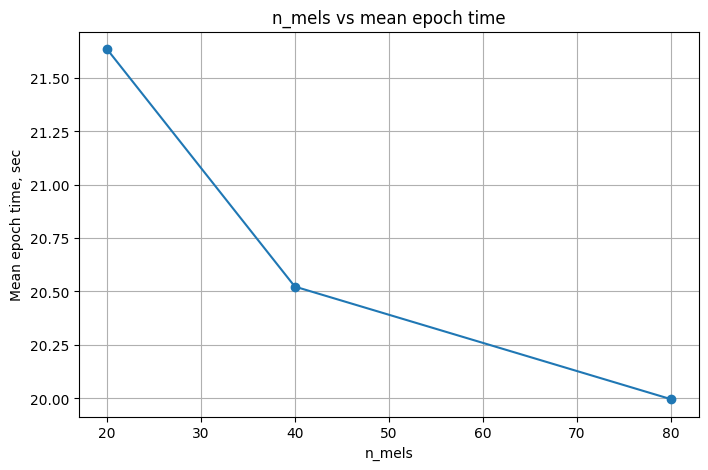

In [29]:
plt.figure(figsize=(8, 5))
for r in n_mels_results:
    plt.plot(r["history"]["train_loss"], marker="o", label=f'n_mels={r["n_mels"]}')
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Train loss for different n_mels")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(n_mels_table["n_mels"], n_mels_table["test_acc"], marker="o")
plt.xlabel("n_mels")
plt.ylabel("Test accuracy")
plt.title("n_mels vs test accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(n_mels_table["n_mels"], n_mels_table["mean_epoch_time_sec"], marker="o")
plt.xlabel("n_mels")
plt.ylabel("Mean epoch time, sec")
plt.title("n_mels vs mean epoch time")
plt.grid(True)
plt.show()

In [30]:
best_n_mels_result = max(n_mels_results, key=lambda x: x["best_val_acc"])
baseline_n_mels = best_n_mels_result["n_mels"]
baseline_n_mels

20

In [31]:
groups_values = [1, 2, 4, 8, 16]

groups_results = []

for groups in groups_values:
    result = train_and_evaluate(
        n_mels=baseline_n_mels,
        groups=groups,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device,
    )
    groups_results.append(result)

epoch=01 | n_mels=20 | groups=1 | train_loss=0.2080 | train_acc=0.9284 | val_loss=0.0951 | val_acc=0.9726 | time=20.58s
epoch=02 | n_mels=20 | groups=1 | train_loss=0.0924 | train_acc=0.9703 | val_loss=0.0703 | val_acc=0.9726 | time=19.56s
epoch=03 | n_mels=20 | groups=1 | train_loss=0.0720 | train_acc=0.9750 | val_loss=0.1255 | val_acc=0.9465 | time=20.62s
epoch=04 | n_mels=20 | groups=1 | train_loss=0.0520 | train_acc=0.9821 | val_loss=0.0633 | val_acc=0.9738 | time=19.50s
epoch=05 | n_mels=20 | groups=1 | train_loss=0.0455 | train_acc=0.9854 | val_loss=0.0328 | val_acc=0.9875 | time=20.71s
epoch=06 | n_mels=20 | groups=1 | train_loss=0.0307 | train_acc=0.9907 | val_loss=0.0519 | val_acc=0.9826 | time=19.49s
epoch=07 | n_mels=20 | groups=1 | train_loss=0.0282 | train_acc=0.9898 | val_loss=0.0558 | val_acc=0.9726 | time=20.86s
epoch=08 | n_mels=20 | groups=1 | train_loss=0.0319 | train_acc=0.9877 | val_loss=0.0380 | val_acc=0.9776 | time=19.56s
epoch=09 | n_mels=20 | groups=1 | train_

In [32]:
groups_table = pd.DataFrame([
    {
        "n_mels": r["n_mels"],
        "groups": r["groups"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "test_loss": r["test_loss"],
        "mean_epoch_time_sec": r["mean_epoch_time_sec"],
        "params_trainable": r["params_trainable"],
        "flops": r["flops"],
    }
    for r in groups_results
])

groups_table = groups_table.sort_values("groups").reset_index(drop=True)
groups_table

,n_mels,groups,best_val_acc,test_acc,test_loss,mean_epoch_time_sec,params_trainable,flops
0,20,1,0.988792,0.997573,0.010606,20.156318,68866,5498880.0
1,20,2,0.993773,0.993932,0.016055,19.947621,38146,3450880.0
2,20,4,0.992528,0.996359,0.014937,20.011206,22786,2426880.0
3,20,8,0.990037,0.991505,0.022820,19.949978,15106,1914880.0
4,20,16,0.987547,0.993932,0.022822,19.883206,11266,1658880.0


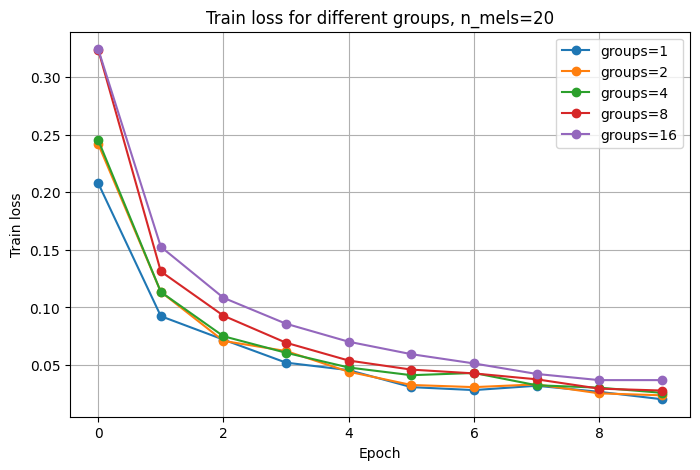

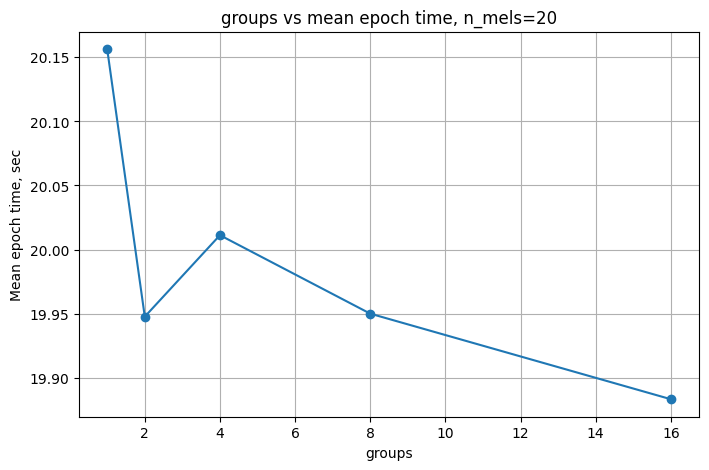

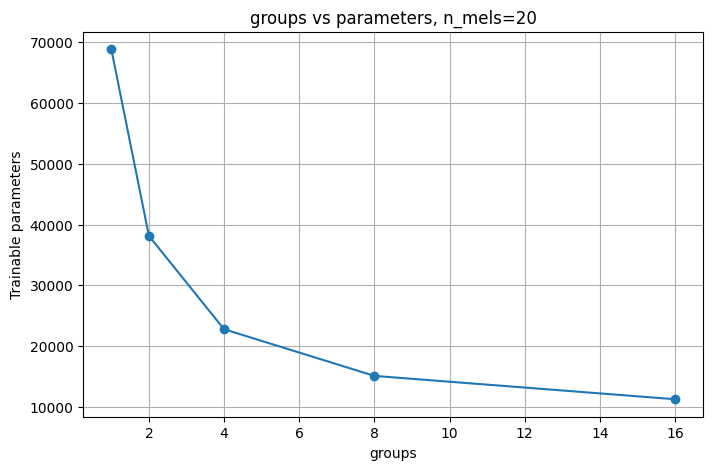

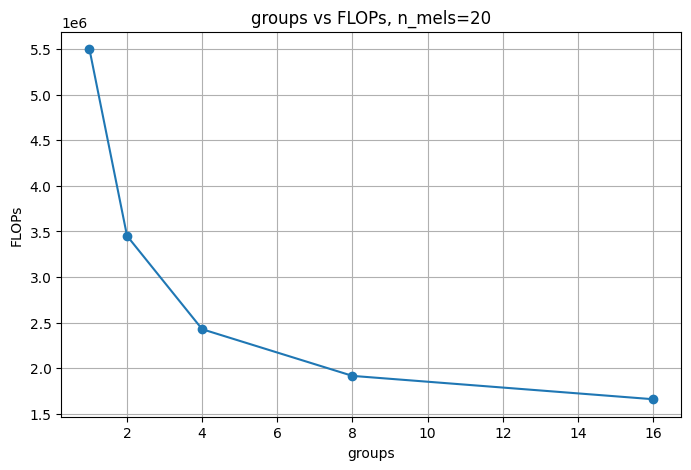

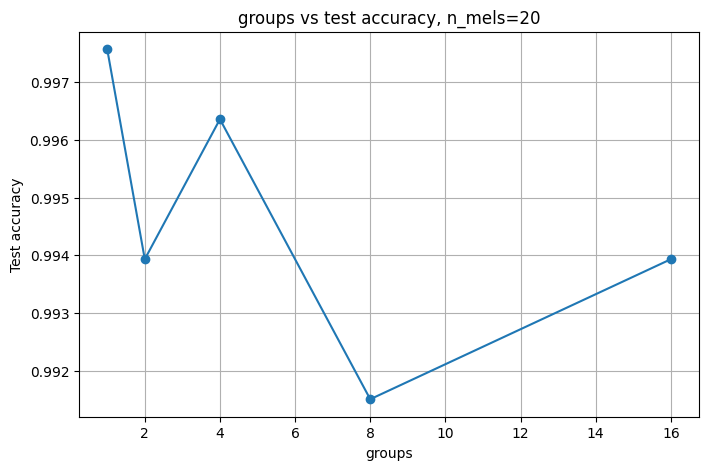

In [33]:
plt.figure(figsize=(8, 5))
for r in groups_results:
    plt.plot(r["history"]["train_loss"], marker="o", label=f'groups={r["groups"]}')
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title(f"Train loss for different groups, n_mels={baseline_n_mels}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(groups_table["groups"], groups_table["mean_epoch_time_sec"], marker="o")
plt.xlabel("groups")
plt.ylabel("Mean epoch time, sec")
plt.title(f"groups vs mean epoch time, n_mels={baseline_n_mels}")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(groups_table["groups"], groups_table["params_trainable"], marker="o")
plt.xlabel("groups")
plt.ylabel("Trainable parameters")
plt.title(f"groups vs parameters, n_mels={baseline_n_mels}")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(groups_table["groups"], groups_table["flops"], marker="o")
plt.xlabel("groups")
plt.ylabel("FLOPs")
plt.title(f"groups vs FLOPs, n_mels={baseline_n_mels}")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(groups_table["groups"], groups_table["test_acc"], marker="o")
plt.xlabel("groups")
plt.ylabel("Test accuracy")
plt.title(f"groups vs test accuracy, n_mels={baseline_n_mels}")
plt.grid(True)
plt.show()

In [34]:
n_mels_table

,n_mels,groups,best_val_acc,test_acc,test_loss,mean_epoch_time_sec,params_trainable,flops
0,20,1,0.990037,0.996359,0.013378,21.635016,68866,5498880.0
1,40,1,0.988792,0.990291,0.036777,20.522932,75266,6791680.0
2,80,1,0.986301,0.991505,0.023296,19.996228,88066,9377280.0


In [35]:
groups_table

,n_mels,groups,best_val_acc,test_acc,test_loss,mean_epoch_time_sec,params_trainable,flops
0,20,1,0.988792,0.997573,0.010606,20.156318,68866,5498880.0
1,20,2,0.993773,0.993932,0.016055,19.947621,38146,3450880.0
2,20,4,0.992528,0.996359,0.014937,20.011206,22786,2426880.0
3,20,8,0.990037,0.991505,0.022820,19.949978,15106,1914880.0
4,20,16,0.987547,0.993932,0.022822,19.883206,11266,1658880.0
